# Notes
* I'm not sure I should include a cleaner in the pptx indexing pipeline - could removing empty lines mess up the splitter? After all, \n\n is one of the default separators
* For a given document, if the tagger identifies different tags for different chunks, perhaps we should take all of the tags and use them for all chunks just to make sure we don't miss anything. There's a lot of overlap between disciplines anyway.
* If the tagger returns nothing
    * Should we remove the entry?
    * Should we just take the tags from all other entries and tag the empty entries with those tags?
    * It's not necessarily the shortest chunks that are untagged btw
* The output of the the recursive splitter does not include the split overlap information or the source ID, and the page numbers are wrong
    * The issue is not because of PDF vs. PPTX
    * The issue is not because I used `\f` as a separator
* <s>Test 3 files</s>
* New strategy:
    * <s>Split MLOps/DevOps/Cloud/Networking into another category</s>
    * Ask the LLM for one tag per chunk
    * After tagging, keep all tags that show up in >= 30% of chunks. All tagged chunks will be tagged with these.
    * For now, keep untagged chunks for evaluation, but eventually, these chunks will be dropped from the database
* Run on all files
* Evaluate content tagging based on course type. Training and validation metrics.
* Or manually label some chunks from non-pptx formats and get evaluation metrics (generalization)
* Try multi-label tagging
* Try multi-label tagging and tagging all tagged entries with the same list
* Run RAG for sanity check - update prompt with title metadata instead of page (since page isn't correct)

# Download files

In [1]:
import sys
from dotenv import load_dotenv
import os

load_dotenv(override=True)

if "../app/" not in sys.path:
    sys.path.append("../app/")

print(sys.path)

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ryanwtsai/repos/lms-ai-agent/app/venv/lib/python3.12/site-packages', '../app/']


In [6]:
import boto3, re

s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_REGION"),
)

In [7]:
bucket_name = "content-tagging-lms"

files = [d["Key"] for d in s3_client.list_objects(Bucket=bucket_name)["Contents"] if re.search(".pptx", d["Key"])]

for file in files:
    print(file)

# for file in files:
#     print(file)
#     head, _ = os.path.split(file)
#     print(head)
#     os.makedirs(head, exist_ok=True)
#     s3_client.download_file(bucket_name, file, file)

Content/AWS introduction/AWS VPC & Networking.pptx
Content/AWS introduction/Introduction to AWS.pptx
Content/AWS introduction/Introduction to Cloud.pptx
Content/AWS introduction/Introduction to EC2.pptx
Content/AWS introduction/Introduction to S3.pptx
Content/AWS introduction/RDS-Lecture.pptx
Content/Data Visualization/4.2-Introduction to Metabase (BI).pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Copy of 10.2 Search Engine.pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Copy of 10.3 Summary.pptx
Content/Large Language Model ( LLM)/Part_10_LLM_Use_Cases-20250225T182513Z-001/Part_10_LLM_Use_Cases/Time_Series/Copy of m3.1-data-prep-timeseries-lecture.pptx
Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx
Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Collection/Lecture_LLM_Data_Collection.pptx
Con

# Use pipeline to chunk

In [4]:
collection_name = "pptx_fixed_chunk_new_tagging"

In [5]:
from haystack_utilities.pipelines import build_indexing_pipeline

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 100,
    "split_overlap": 20,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 200,
    "split_overlap": 40,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 300,
    "split_overlap": 60,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "fixed",
    "split_by": "word",
    "split_length": 300,
    "split_overlap": 60,
    "split_threshold": 300,
    "respect_sentence_boundary": True
}

index_pipe = build_indexing_pipeline(collection_name, splitting_options, file_extension=".pptx", max_content_len_chars=65535, drop_old=True)
# index_pipe = build_indexing_pipeline(collection_name, splitting_options, file_extension=".pptx", max_content_len_chars=65535, drop_old=False)

In [ ]:
fnames = ["Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx"]
# fnames = ["Content/AWS introduction/Introduction to AWS.pptx"]
# fnames = ["Content/Data Visualization/4.2-Introduction to Metabase (BI).pptx"]
fnames = ["Content/Large Language Model ( LLM)/Part_9_RAG-20250225T182503Z-001/Part_9_RAG/Lecture_RAG_Introduction.pptx", "Content/Large Language Model ( LLM)/Part_3_Data_Preparation/Data_Annotation/Lecture_LLM_Data_Labelling.pptx"]
fnames = files

index_results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "cleaner", "splitter"})
# results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "splitter"})
index_results

No abbreviations file found for en. Using default abbreviations.


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

{'writer': {'documents_written': 36},
 'converter': {'documents': [Document(id=5388872f8848bcf1dcabba93e2cef6aacd1326ca69927c06e9e159bd3a6a6b81, content: 'Retriever Augmentated Generation (RAG)
   
   RAG
   Why LLMs doesn’t make good conversational systems
   Agenda...', meta: {'file_path': 'Lecture_RAG_Introduction.pptx'}),
   Document(id=f15c17ca5e0a259fcb7c1bcfb791ef1bfeb5f344a3216ea0a03a7d0ef0fffd73, content: '
   Data Labeling 
   For Natural Language Processing
   This module so far
   
   Why do we need datasets of any k...', meta: {'file_path': 'Lecture_LLM_Data_Labelling.pptx'})]},
 'cleaner': {'documents': [Document(id=30b330a1bb49514a70ec5a2092b2627bb76740da865949fb5a610952a14c0d48, content: 'Retriever Augmentated Generation (RAG)
   RAG
   Why LLMs doesn’t make good conversational systems
   Agenda....', meta: {'file_path': 'Lecture_RAG_Introduction.pptx'}),
   Document(id=598dd204042d6f6780a03e201eafb41ec6019a7d7f0ab52add3805aed3b74eb0, content: 'Data Labeling For Natural

In [225]:
if "splitter" in index_results.keys():
    lengths = [len(doc.content) for doc in index_results["splitter"]["documents"]]
    print(f"Max len char = {max(lengths)}")
    print(f"Min len char = {min(lengths)}")

Max len char = 2838
Min len char = 203


(array([ 3.,  6.,  1.,  1.,  4., 30., 64., 13.,  4.,  2.]),
 array([ 203. ,  466.5,  730. ,  993.5, 1257. , 1520.5, 1784. , 2047.5,
        2311. , 2574.5, 2838. ]),
 <BarContainer object of 10 artists>)

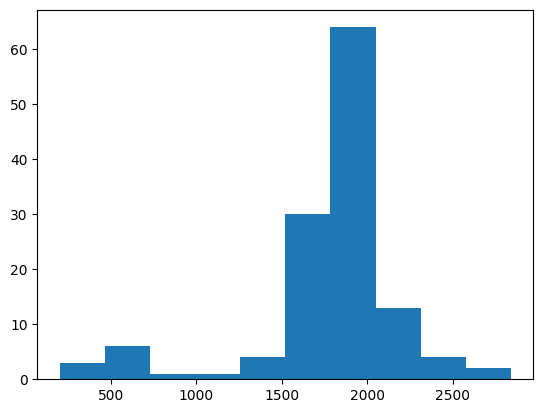

In [226]:
import matplotlib.pyplot as plt

plt.hist(lengths)

In [160]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")

component_names = ["converter", "cleaner"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"
        with open(fname, "w") as file:
            file.write(index_results[name]["documents"][0].content)
            print(f"{fname} written.")


component_names = ["splitter"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in index_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/converter_output.txt written.
./experiments/cleaner_output.txt written.
./experiments/splitter_output.txt written.


# Use pipeline to tag

In [18]:
from haystack_utilities.pipelines import build_tagging_pipeline

# V1
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Other].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Generative AI, Natural Language Processing, Large Language Models, Computer Vision, MLOps
    * Data Science: Statistics, Predictive Modeling, Feature Engineering, Data Science
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Visualization
    * Data Engineering: Data Pipelines, Big Data, Cloud Engineering, DevOps, Spark
    * Other: Web Scraping

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V2
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering:
        - Fine-Tuning, Parameter-Efficient Fine-Tuning (PEFT), Low-Rank Adaptation (LoRA)
        - AI, Generative AI (GenAI), AI Agent
        - Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering
        - Retrieval-Augmented Generation (RAG), Vector Databases, Vector Search, Chunking
        - Computer Vision
    * Data Science:
        - Statistical Modeling, Statistical Analysis, Statistics
        - Feature Engineering
        - Classic Information Retrieval, BM25, TF-IDF, Bag of Words
    * Data Analysis:
        - Business Intelligence (BI)
        - SQL, Excel
        - Exploratory Data Analysis (EDA)
        - Data Visualization, Reporting
    * Data Engineering:
        - ETL, Data Pipelines, Data Collection, Data Cleaning, Web Scraping
        - Big Data, Spark, Hadoop, Kafka
    * Infrastructure and Operations:
        - MLOps, Model Deployment
        - DevOps, CI/CD
        - Cloud, AWS, GCP, Azure
        - Distributed Systems
        - Networking

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V3
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: Machine Learning, Fine-Tuning, Artificial Intelligence (AI), Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering, Retrieval-Augmented Generation (RAG), Computer Vision
    * Data Science: Data Science, Statistical Analysis, Statistical Modeling, Feature Engineering
    * Data Analysis: Data Analysis, Analytics, Business Intelligence (BI), SQL, Excel, Data Visualization
    * Data Engineering: Data Engineering, ETL, Data Wrangling, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Networks

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V4
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Natural Language Processing, Large Language Models, Prompt Engineering, Retrieval-Augmented Generation, Similarity Search, Vector Search, Vector Index, Computer Vision
    * Data Science: Statistical Analysis, Statistical Modeling, Feature Engineering, Data Annotation, Data Labeling
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Data Visualization
    * Data Engineering: ETL, Data Wrangling, Deduplication, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Networks

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# V5
prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Natural Language Processing, Large Language Models, Prompt Engineering, Retrieval-Augmented Generation, Similarity Search, Vector Search, Vector Index, Computer Vision
    * Data Science: Statistical Analysis, Statistical Modeling, Feature Engineering, Data Annotation, Data Labeling
    * Data Analysis: Data Analytics, Business Intelligence, SQL, Excel, Data Visualization
    * Data Engineering: ETL, Data Wrangling, Deduplication, Data Pipelines, Big Data (Spark, Hadoop, Kafka), Data Storage, Web Scraping
    * Infrastructure and Operations: MLOps, Model Deployment, Model Monitoring, DevOps, CI/CD, Cloud (AWS, GCP, Azure), Computer Networks, Distributed Computing

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

# # ChatGPT
# prompt_template_tagging = """
#     I am doing a content tagging project. The goal of the project is to tag teaching materials.

#     Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Infrastructure and Operations].

#     Here are some examples of topics for each tag:
#     * **Machine Learning Engineering:**
#         - Fine-Tuning, Parameter-Efficient Fine-Tuning (PEFT), Low-Rank Adaptation (LoRA)
#         - AI, Generative AI (GenAI), AI Agents
#         - Natural Language Processing (NLP), Large Language Models (LLM), Prompt Engineering
#         - Retrieval-Augmented Generation (RAG), Vector Databases, Vector Search, Chunking
#         - Computer Vision, Object Detection, Image Classification
#     * **Data Science:**
#         - Statistical Modeling, Statistical Analysis, Hypothesis Testing
#         - Feature Engineering, Data Transformation
#         - Classic Information Retrieval, BM25, TF-IDF, Bag of Words
#         - Machine Learning Algorithms (e.g., Regression, Classification)
#     * **Data Analysis:**
#         - Business Intelligence (BI), Reporting
#         - SQL, Excel, Data Querying
#         - Exploratory Data Analysis (EDA), Descriptive Statistics
#         - Data Visualization (e.g., Tableau, Power BI)
#     * **Data Engineering:**
#         - ETL (Extract, Transform, Load), Data Pipelines, Data Collection, Data Cleaning
#         - Big Data Technologies: Spark, Hadoop, Kafka
#         - Data Storage (Databases, Data Lakes, Warehouses)
#         - Web Scraping, Data Wrangling
#     * **Infrastructure and Operations:**
#         - MLOps, Model Deployment, Model Monitoring
#         - DevOps, CI/CD (Continuous Integration/Continuous Delivery)
#         - Cloud Platforms: AWS, GCP, Azure
#         - Distributed Systems, Load Balancing
#         - Networking, VPNs, Cloud Networking

#     I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

#     Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineering"].
    
#     Respond only with the list, no other text.

#     If none of the tags apply, respond with an empty list, [].

#     Text chunk: ```{{doc.content}}```
#     """

tag_pipe = build_tagging_pipeline(collection_name, prompt_template_tagging)

In [19]:
tag_results = tag_pipe.run({})

tag_results

{'upserter': {'documents_written': 36}}

# Check tagging results

In [20]:
from pymilvus import MilvusClient
import os
from dotenv import load_dotenv

load_dotenv(override=True)

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN")
)

In [21]:
tags = ["Machine Learning Engineering", "Data Analysis", "Data Engineering", "Data Science", "Infrastructure and Operations", "Other"]
# fname = 'Introduction to AWS.pptx'
# fname = "4.2-Introduction to Metabase (BI).pptx"

for tdx, tag in enumerate(tags):
    filter = f"json_contains(metadata['tags'], '{tag}')"
    # filter = f"json_contains(metadata['tags'], '{tag}') AND metadata['title'] == '{fname}'"
    res = client.query(
        collection_name=collection_name,
        filter=filter,
        output_fields=["text", "metadata"],
    )
    
    n_chunks = len(res)
    print(f"{tag}: {n_chunks}")

    # if os.path.exists(f"./experiments/tagged_chunks_{tdx}.txt"):
    #     os.remove(f"./experiments/tagged_chunks_{tdx}.txt")
    
    # with open(f"./experiments/tagged_chunks_{tdx}.txt", "a") as file:
    #     for r in res:
    #         # file.write(f"{r['text']}\n{"-"*100}\n\n")
    #         # file.write(r["metadata"]["title"])
    #         file.write(f"{r['text']}\n\n")
    #         file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

    fname = f"./experiments/tagged_chunks_{tag}_{n_chunks}.txt"
    if os.path.exists(fname):
        os.remove(fname)
    
    with open(fname, "a") as file:
        for r in res:
            # file.write(f"{r['text']}\n{"-"*100}\n\n")
            # file.write(r["metadata"]["title"])
            file.write(f"{r['text']}\n\n")
            file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

Machine Learning Engineering: 18
Data Analysis: 0
Data Engineering: 0
Data Science: 17
Infrastructure and Operations: 0
Other: 0


In [22]:
filter = 'metadata["tags"] == []'
# filter = f"metadata['tags'] == [] AND metadata['title'] == '{fname}'"
res = client.query(
    collection_name=collection_name,
    filter=filter,
    output_fields=["text", "metadata"],
)

n_chunks = len(res)
print(n_chunks)

fname = f"./experiments/untagged_chunks_{n_chunks}.txt"
if os.path.exists(fname):
    os.remove(fname)

with open(fname, "a") as file:
    for r in res:
        file.write(f"{r['text']}\n\n")
        file.write(f"{r['metadata']['title']}\n{"-"*100}\n")

1


In [14]:
lengths = [len(r['text']) for r in res]
print(lengths)

[1775]


# Sanity-check retrieval and generation

In [ ]:
from haystack_utilities.pipelines import build_rag_pipeline

prompt_rag = """
You will be provided some context, followed by the page number that this context comes from.
Answer the question based on the contexts, and reference the page numbers from which your answer is generated.

Context:
{% for doc in documents %}
   {{ doc.content }} 
   Page: {{ doc.meta['metadata']["page_number"]}}
   -----
{% endfor %}
-----
Question: {{ query }}
-----
Answer:
"""

# prompt_rag = """
# Please answer the question. Ignore the context provided.

# Context:
# {% for doc in documents %}
#    {{ doc.content }} 
#    Page: {{ doc.meta['metadata']["page_number"]}}
#    -----
# {% endfor %}
# -----
# Question: {{ query }}
# -----
# Answer:
# """

rag_pipe = build_rag_pipeline(collection_name, prompt_rag, top_k=3)

In [ ]:
query = "How can I use LLMs to assist in labeling datasets?"
query = "Please provide a detailed step-by-step instruction for labeling a dataset with LLM assistance, e.g. Step 1, Step 2, Step 3, etc."
# query = "How many teams are there in the NBA?"

In [74]:
rag_results = rag_pipe.run({"query_embedder": {"text": query}, "prompt_builder": {"query": query}}, include_outputs_from={"retriever", "prompt_builder"})

rag_results

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{'generator': {'replies': ['There are 30 teams in the NBA.'],
  'meta': [{'model': 'gpt-4o-mini-2024-07-18',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 10,
     'prompt_tokens': 1481,
     'total_tokens': 1491,
     'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0),
     'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cached_tokens=1408)}}]},
 'retriever': {'documents': [Document(id=c545efd7008e1bd4369699b58052be9a2dbeefcecdd9298d1db923d3b9d28f61, content: 'we classify the following texts: I’m sure the {@Tampa Bay Lightning@} would’ve rather faced the Flye...', meta: {'metadata': {'tags': [], 'source_id': None, 'title': 'Lecture_LLM_Data_Labelling.pptx', 'page_number': 12, 'split_overlap_ids': []}}, score: 0.030396653339266777, embedding: vector of size 768),
   Document(id=500cdbf22e4a26168bb750df6d06d8b3f855ddc88511d2e03137da663477d6ef, 

In [75]:
if "prompt_builder" in rag_results:
    print(rag_results["prompt_builder"]["prompt"])


Please answer the question. Ignore the context provided.

Context:

   we classify the following texts: I’m sure the {@Tampa Bay Lightning@} would’ve rather faced the Flyers but man does their experience versus the Blue Jackets this year and last help them a lot versus this Islanders team. Another meat grinder upcoming for the good guys #repost {@Shantel VanSanten@} ・・・ 107 degrees before noon?!?!? Labor day weekend plans are to live in my pool this weekend!! #CanISleepFloatingInThePool #WrinklyFingers {{URL}} Queen {@Aditi Rao Hydari@} is replying to many I hope the queenwill also reply me #V iOS 14 literally gave me the keys to ignoring unwanted calls and carrying on as if nothing happened. Thank you {@Apple@} Hi {{USERNAME}} , we are currently conducting some research around the food stall business in the UK and would love it if you were able to spare a few minutes to complete the survey in the link below, would be great to have your input!! {{URL}} How do you do manual labeling? L

In [76]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")
        
fname = f"./experiments/generator_output.txt"
with open(fname, "w") as file:
    file.write(rag_results["generator"]["replies"][0])
    print(f"{fname} written.")


component_names = ["retriever"]

for name in component_names:
    if name in rag_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in rag_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/generator_output.txt written.
./experiments/retriever_output.txt written.


# Drop collection

In [3]:
client.list_collections()
# client.drop_collection("pptx2")

NameError: name 'client' is not defined